In [ ]:
## pip install -U langchain langchain-community langchain-core langchain-text-splitters langchain-huggingface langgraph

  Using cached langchain-1.2.15-py3-none-any.whl.metadata (5.8 kB)
Using cached langchain-1.2.15-py3-none-any.whl (112 kB)
  Attempting uninstall: langchain
    Found existing installation: langchain 0.3.26
    Uninstalling langchain-0.3.26:
      Successfully uninstalled langchain-0.3.26
Note: you may need to restart the kernel to use updated packages.


In [2]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
docs = (
    PyPDFLoader(r"D:\Education\Machine Learning\Machine learning Project\AGENTICLANGGRAPH\8-RAG\Data\company_policy.pdf").load()
    + PyPDFLoader(r"D:\Education\Machine Learning\Machine learning Project\AGENTICLANGGRAPH\8-RAG\Data\company_profile.pdf").load()
    + PyPDFLoader(r"D:\Education\Machine Learning\Machine learning Project\AGENTICLANGGRAPH\8-RAG\Data\product_launch_pricing.pdf").load()
)

In [4]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [5]:
from langchain_huggingface import HuggingFaceEmbeddings

embd = HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2",
        model_kwargs={'device': 'cpu'},
        encode_kwargs={'normalize_embeddings': True}
    )

print(embd.embed_query("hello world"))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[-0.034477297216653824, 0.031023187562823296, 0.006734919734299183, 0.026108957827091217, -0.03936200961470604, -0.16030246019363403, 0.06692399084568024, -0.006441456265747547, -0.047450486570596695, 0.014758874662220478, 0.07087532430887222, 0.055527616292238235, 0.019193338230252266, -0.026251329109072685, -0.01010952703654766, -0.02694045379757881, 0.022307459264993668, -0.02222668193280697, -0.14969265460968018, -0.017493000254034996, 0.007676252163946629, 0.05435226857662201, 0.0032544017303735018, 0.031725894659757614, -0.08462140709161758, -0.029405973851680756, 0.05159560218453407, 0.04812406376004219, -0.0033148550428450108, -0.05827920883893967, 0.04196922853589058, 0.02221068926155567, 0.1281888484954834, -0.02233894169330597, -0.011656275950372219, 0.06292840093374252, -0.03287636116147041, -0.09122602641582489, -0.03117535077035427, 0.05269957333803177, 0.04703487455844879, -0.0842030718922615, -0.030056193470954895, -0.02074483223259449, 0.009517823345959187, -0.00372179

In [8]:
vectorstore = FAISS.from_documents(chunks, embd)
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

In [9]:
from langchain_groq import ChatGroq
import os 

#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="qwen/qwen3-32b")
#llm = ChatOpenAI(model="gpt-4o")
result=llm.invoke("Hello")
result

AIMessage(content='<think>\nOkay, the user said "Hello". That\'s a greeting. I should respond in a friendly and welcoming way. Let me make sure to acknowledge their greeting and offer assistance. Maybe something like "Hello! How can I assist you today?" That should cover it. I need to keep it open-ended so they feel comfortable asking anything. No need for any markdown here since it\'s just a simple greeting. Alright, ready to go.\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 103, 'prompt_tokens': 9, 'total_tokens': 112, 'completion_time': 0.192024167, 'prompt_time': 0.000278746, 'queue_time': 0.006469871, 'total_time': 0.192302913}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dab7a-8531-7372-b31c-3c103f5b2075-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'out

In [10]:
# Graph State
# --------------------------------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]

    answer: str

In [11]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

In [14]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }

In [15]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [16]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

In [19]:
graph=StateGraph(State)

## Node
graph.add_node("decide_retrieval",decide_retrieval)
graph.add_node("generate_direct",generate_direct)
graph.add_node("retrieve",retrieve)


graph.add_edge(START,"decide_retrieval")
graph.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct":"generate_direct",
        "retrieve":"retrieve",
    }

)
graph.add_edge("generate_direct",END)
graph.add_edge("retrieve",END)


In [20]:
app=graph.compile()

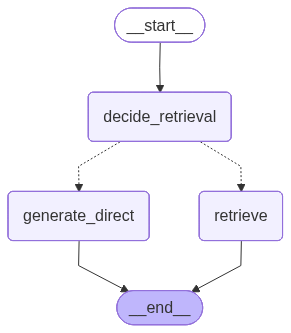

In [21]:
app

In [22]:
result = app.invoke(
    {
        "question": "What is Machine Learning",
        "need_retrieval": False,
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])

<think>
Okay, the user is asking what machine learning is. Let me start by recalling my general knowledge on the subject.

Machine learning is a subset of artificial intelligence. It involves algorithms that can learn from and make predictions or decisions based on data. Unlike traditional programming where you write explicit instructions, machine learning models improve their performance with experience over time.

I should mention the different types of machine learning. There's supervised learning, where the model is trained on labeled data. Examples include classification and regression. Then there's unsupervised learning, which deals with unlabeled data, like clustering. Reinforcement learning is another type where an agent learns by interacting with an environment, getting rewards or penalties.

Applications are important to include. Things like recommendation systems, image recognition, natural language processing, and autonomous vehicles all use machine learning. It's used in v

In [23]:
result = app.invoke(
    {
        "question": "Tell me about the about of the company",
        "need_retrieval": True,
        "docs": [],
        "answer": "",
    }
)

print(result["answer"])

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '{"should_retrieve": true}'}}